# Symmetry and invariant reduction

Symmetry methods are reduction tools rather than always the final solver. We use the transport equation to inspect how a symmetry preference competes with a simpler direct characteristic route.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Invariant DerivationFor $u_t+u_x=0$, simultaneous translation in $x$ and $t$ leaves the equation invariant. The characteristic/invariant coordinate$$\xi=x-t$$reduces the PDE to constancy along the complementary direction, giving$$u=F(x-t).$$A symmetry reducer and a direct characteristic solver can therefore arrive at the same reduced structure by different routes.

In [3]:
x,t=sp.symbols("x t", real=True)
u=sp.Function("u")
eq=sp.Eq(sp.diff(u(x,t),t)+sp.diff(u(x,t),x),0)
problem=pds.build_pde_problem(eq,u(x,t),(x,t))
recognition, plan=show_plan(problem)

Recognition: (PDERecognitionRecord(family='scalar_conservation_law', recognized=True, solver_hint='conservation_law', tags=('weak_solution', 'riemann_ready'), metadata={'canonical_family': 'transport_reaction'}), PDERecognitionRecord(family='first_order_linear', recognized=True, solver_hint='first_order', tags=('characteristics',), metadata={'constant_coefficient': True}))Top plan steps:  constant_coefficient_inverse_operator      score=92  first_order                                score=76  conservation_law                           score=74  symmetry_reduction                         score=52  post_reduction_auto                        score=48

In [4]:
result=pds.pdesolve(eq,u(x,t),(x,t),method="auto",prefer_symmetry=True,max_symmetry_steps=1)
print(type(result).__name__,result.method)
display(result.solution)
print("Verification:",result.verification)

PDESolutionRecord pdsolve_first_order_linear

Verification: {'verified': True, 'status': 'verified', 'pde_verified': True, 'initial_verified': None, 'boundary_verified': None, 'pde_residual': 0, 'initial_residuals': (), 'boundary_residuals': (), 'mode': 'symbolic', 'message': ''}

## 2. What should be verified?If reduction plus postsolve produces an explicit family, verify it against the original PDE. If only a reduced equation is obtained, `UnsolvedButReducedResult` is progress rather than a solved-PDE claim.

In [5]:
sol=rhs_of(result.solution)
print("Residual of returned family:", residual(eq,u(x,t),sol))
assert residual(eq,u(x,t),sol)==0

Residual of returned family: 0

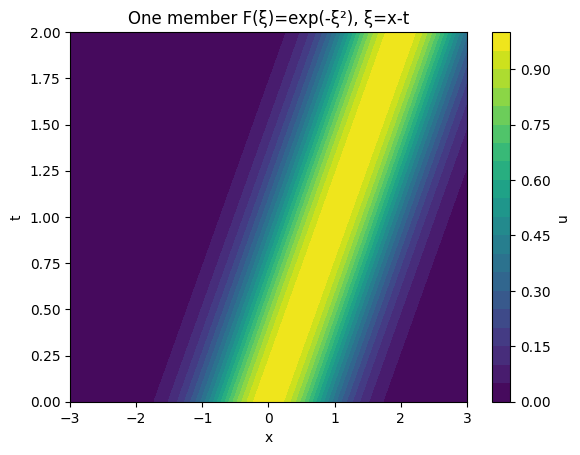

In [6]:
xx=np.linspace(-3,3,300); tt=np.linspace(0,2,120); X,T=np.meshgrid(xx,tt); Z=np.exp(-(X-T)**2)
fig,ax=plt.subplots(); cs=ax.contourf(X,T,Z,levels=20); fig.colorbar(cs,ax=ax,label="u")
ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title("One member F(ξ)=exp(-ξ²), ξ=x-t"); plt.show()

## 3. Variation and exercisesRun the same equation without the symmetry preference. Then: (1) compare the plans; (2) explain why a preference is not an absolute command; (3) choose a specific $F$ and verify the resulting solution directly.

In [7]:
r2=pds.pdesolve(eq,u(x,t),(x,t),method="auto")
print("Without symmetry preference:",r2.method); display(r2.solution)

Without symmetry preference: constant_coefficient_homogeneous_family